<!-- SPDX-License-Identifier: Apache-2.0 -->

# The digital half of a SAR ADC: RTL, verification, and an open RTL-to-GDS flow in sky130

### Submission to the IEEE SSCS Open-Source Ecosystem "Code-a-Chip" Travel Grant Awards at ISSCC'27

SPDX-License-Identifier: Apache-2.0

| Name | Affiliation | IEEE Member | SSCS Member | Email |
|---|---|---|---|---|
| Joyce Berdkan | The George Washington University | Yes | Yes | j.berdkan@gwu.edu |

---

## Introduction

A companion notebook builds an 8-bit SAR ADC in sky130 and spends its length arguing with its own
analog measurements. This one is about the part of that converter that is *digital*: the
successive-approximation sequencer, taken from a 774-device transistor netlist to synthesisable
RTL, verified, and pushed through a complete open-source RTL-to-GDS flow on sky130.

The reason to write the sequencer twice is that the two versions disagree, and the disagreements
are the interesting part. A transistor netlist and an RTL module are two statements of the same
intent, and where they differ, one of them is wrong. Finding out which is a cheap and unusually
honest form of review — much cheaper than the seven weeks the analog side spent on a bug that
was visible in its first printed line of output.

Two differences turned up. Neither was caught by the testbench, and one of them **cannot** be:

| what differed | how it was found | could the testbench catch it? |
|---|---|---|
| the MSB's DAC drive lost its sampling-phase term | diffing RTL against the netlist | **no** — demonstrated below |
| `phase` silently dropped its last bit | a width check | yes, once asked |

The second half of the notebook reports an attempt to replicate **OpenLayout** (Li *et al.*,
ICCAD '26) — an agentic, multi-agent physical-design framework from this department — on this
design. It runs, it produces a clean layout, and getting there surfaced five things about the
open-source release that are worth writing down.

## What this notebook is for

It is an **educational** submission, and the thing it tries to teach is not a circuit. It is how
to tell a measurement from a number that merely looks like one.

Every section is built the same way: a claim, then the cheapest experiment that could falsify it,
then whatever that experiment actually said. Section 3 runs a testbench against two builds of the
same module and asserts their output is *identical*, to show that a passing test can be evidence
about the model rather than the circuit. Section 6.1 checks a layout against the PDK's own
sign-off deck rather than trusting a router's report on its own work. Section 8 reports five
defects in a framework — including two runs that printed a confident verdict having compared
nothing at all.

A reader who takes one thing away should take this: **the failure mode that costs weeks is not a
wrong answer, it is a right-looking answer from a check that did not run.** Every example here is
one I hit, and most of them are cheap to catch once you know the shape.

## Acknowledgements

I thank **Dr. Weidong Cao** (Department of Electrical and Computer Engineering, The George
Washington University) for advising this work and for suggesting the direction of agentic,
end-to-end physical design — in particular *OpenLayout* (Li, Tang, Cheng, Wang, Li, Lan and Cao,
ICCAD '26), which this notebook attempts to reproduce. Any errors here are mine.

## Requirements

Everything below runs on a free Google Colab instance from a cold start, with no GPU and no API
key. It is **not** a standard-library-only notebook and it is not a two-minute one; here is
everything it fetches, and where:

| what | where | why |
|---|---|---|
| **Icarus Verilog** | §1, `apt-get` | compiles and runs the RTL and testbenches |
| **gdstk** | §6.1, `pip` | reads the embedded GDS |
| **matplotlib** | §6.1 | renders the layout |
| **KLayout binary + zstd** | §6.1, `apt-get` | the pip module has no Ruby DRC engine |
| **sky130 rule deck** | §6.1, 6.6 MB from `volare` | `sky130A_mr.drc`, pinned by commit |

The last four are fetched by Section 6.1 when you reach it, not up front, so Sections 1–5 run on
Icarus Verilog alone. **The end-to-end runtime is measured, not estimated** — the final cell
prints the elapsed time for whatever machine ran it, which is the only figure worth quoting.

The physical-implementation results — synthesis, placement, CTS, routing — come from OpenROAD
with the sky130 and Nangate45 open PDKs. Those runs are **reported as records** rather than
re-run here, because they need a ~10 GB toolchain; every one is reproducible with the commands
given in Section 6, and the *arguments* they support are reproduced here from first principles.

---
## 1. Environment

In [1]:
import subprocess, sys, os, time, textwrap, pathlib
T_START = time.time()        # end-to-end runtime: measured by the last cell, not asserted here

def sh(c):
    r = subprocess.run(c, shell=True, capture_output=True, text=True)
    return (r.stdout or "") + (r.stderr or "")

if subprocess.run("which iverilog", shell=True, capture_output=True).returncode != 0:
    sh("apt-get -qq update && apt-get -qq install -y iverilog")

# stdout only: iverilog writes probe warnings carrying local toolchain paths to
# stderr, and those have no business in a published notebook.
_v = subprocess.run("iverilog -V", shell=True, capture_output=True, text=True).stdout
print(_v.splitlines()[0] if _v.strip() else "iverilog: NOT FOUND")
WORK = pathlib.Path("rtl_work"); WORK.mkdir(exist_ok=True)
# Relative, not resolved: an absolute path here publishes the username of
# whoever ran the notebook last.
print("work dir:", WORK, "(relative to the notebook)")

Icarus Verilog version 12.0 (stable) ()
work dir: rtl_work (relative to the notebook)


---
## 2. The sequencer

The analog sequencer is a one-hot shift register built from transistor-level primitives. Each
conversion runs `N+2` phases: `p[0]` samples, `p[1]..p[N]` are the bit trials, and `p[N+1]` reads
the result out and clears the decision register.

Two details carry the findings from the analog side:

**Capture is on the falling edge.** The comparator precharges *both* outputs high while its clock
is low, so a flip-flop clocked on the phase boundary latches the precharge value rather than the
decision — every trailing bit comes back `1`. The RTL captures `q[i]` on the falling edge of `clk`,
enabled by `p[i+1]`. That is an *enable on a negedge flop*, deliberately not a gated clock: gating
`p[i+1]` onto a clock pin is what the analog version effectively did, and it makes the capture
edge depend on when the gate happens to resolve.

**Read and clear live in their own phase.** In the analog version the code-register clear was
pinned to an absolute time, `9*t_p`, while the last trial's capture landed a quarter phase later
at `9.25*t_p`. The bit was erased before anything read it. That constant is safe at `N` = 6, 10
and 12 and collides only at `N` = 8. Here both read and clear are derived from the one-hot
register, so there is no constant left to disagree with `N` and the bug class cannot recur
silently at any resolution.

In [2]:
SAR_SEQUENCER_V = r"""
// SPDX-License-Identifier: Apache-2.0
//
// sar_sequencer -- one-hot successive-approximation sequencer, MSB first.
//
// Structure matches the transistor-level sequencer it replaces:
//
//   phases      p[0]            sample / reset of the code register's source
//               p[1] .. p[N]    trial 0 .. trial N-1   (trial i is active in p[i+1])
//               p[N+1]          read: load the code register, clear q
//               -> back to p[0]
//
//   DAC drive   d[i] = p[i+1] | q[i]
//                      ^^^^^^   force cap i high for its own trial
//                               ^^^^ hold the decision afterwards
//
//   capture     q[i] <= cmp on the FALLING edge of the phase clock, enabled by p[i+1]
//
// Bit order, because it is easy to read backwards: trial 0 decides the MSB
// (weight 2^(N-1)) and lands in q[0]/code[0]. code[N-1] is the LSB. This is the
// same q0..q7 order as the netlist, NOT the usual byte order where bit 7 is MSB.
// `code_bin` is provided as the conventional weighted value.
//
// -------------------------------------------------------------------------
// Why the phase count is N+2 and why that matters
// -------------------------------------------------------------------------
// The analog sequencer captured trial i a quarter phase past the end of p[i+1],
// and a code-register clear pinned to an absolute time collided with the last
// trial's capture at N = 8 (and only at N = 8). Here read and clear live in
// their own phase, p[N+1], and are derived from the one-hot register rather
// than from a constant. There is no constant left to disagree with N, so the
// bug class cannot recur silently at any N.
//
// -------------------------------------------------------------------------
// Timing constraint this imposes on the implementation flow
// -------------------------------------------------------------------------
// The phase advances on posedge clk and the comparator is captured on negedge
// clk, so the DAC settling + comparator decision path has HALF a clock period,
// not a full one. Constrain it as such; do not let the tool assume a full cycle:
//
//   create_clock -name clk -period ${TP} [get_ports clk]
//   set_output_delay ... [get_ports d[*]]   ;# to the DAC
//   set_input_delay  ... [get_ports cmp]    ;# from the comparator
//   # the d -> cmp loop closes outside this block; budget it explicitly
//
// `cmp` is the registered output of a clocked comparator, so it is already
// synchronous to clk and needs no synchroniser. If that ever stops being true,
// this module is wrong, not the constraint file.

`default_nettype none

module sar_sequencer #(
    parameter integer N = 8                 // resolution in bits
) (
    input  wire              clk,           // phase clock: one period per phase
    input  wire              rst_n,         // active-low async reset
    input  wire              start,         // sampled in p[0]; begins a conversion
    input  wire              cmp,           // comparator output, already clocked

    output wire [N-1:0]      d,             // DAC drive, d[0] = MSB capacitor
    output wire [N+1:0]      phase,         // one-hot over all N+2 phases, for observability
    output reg  [N-1:0]      code,          // MSB-first, code[0] = MSB
    output wire [N-1:0]      code_bin,      // conventional weighting, bit N-1 = MSB
    output reg               eoc            // one clk pulse, asserted in p[N+1]
);

    // ---------------------------------------------------------------- checks
    // Elaboration-time, so a bad parameter fails at compile rather than in a
    // waveform three weeks later.
    generate
        if (N < 2) begin : g_bad_n
            illegal_parameter_N_must_be_at_least_2 err();
        end
    endgenerate

    localparam integer NPH      = N + 2;    // p[0] sample, p[1..N] trials, p[N+1] read
    localparam integer PH_READ  = N + 1;

    // ------------------------------------------------------- phase register
    // One-hot. Held in p[0] until start; then walks to p[N+1] and wraps.
    reg [NPH-1:0] p;

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            p <= {{(NPH-1){1'b0}}, 1'b1};       // p[0]
        end else if (p[0]) begin
            p <= start ? {{(NPH-2){1'b0}}, 2'b10} : {{(NPH-1){1'b0}}, 1'b1};
        end else if (p[PH_READ]) begin
            p <= {{(NPH-1){1'b0}}, 1'b1};       // back to p[0]
        end else begin
            p <= p << 1;
        end
    end

    assign phase = p;          // all NPH bits: [N:0] would drop the read phase p[N+1],
                               // leaving `phase` all-zero for one phase in every N+2.

    // ------------------------------------------------------- decision register
    // Captured on the falling edge of clk, enabled by the active phase. This is
    // an enable on a negedge flop, deliberately NOT a gated clock: gating p[i+1]
    // onto the clock pin is what the analog version effectively did, and it is
    // what makes the capture edge depend on when the gate happens to resolve.
    reg [N-1:0] q;
    integer i;

    always @(negedge clk or negedge rst_n) begin
        if (!rst_n) begin
            q <= {N{1'b0}};
        end else if (p[PH_READ]) begin
            q <= {N{1'b0}};                     // clear, after the last capture
        end else begin
            for (i = 0; i < N; i = i + 1)
                if (p[i+1]) q[i] <= cmp;        // trial i lives in p[i+1]
        end
    end

    // ------------------------------------------------------------- DAC drive
    genvar b;
    generate
        for (b = 0; b < N; b = b + 1) begin : g_dac
            if (b == 0) begin : g_msb
                // The MSB additionally holds through the sampling phase p[0].
                // Without this term every bottom plate is grounded the instant
                // sampling ends, the top plate sits at Vcm - Vin -- negative for
                // any input above Vcm -- and the substrate diode clamps it,
                // destroying the charge just sampled. This matches or{0}a in the
                // netlist: d0 = p0 | p1 | q0.
                assign d[b] = p[0] | p[b+1] | q[b];
            end else begin : g_rest
                assign d[b] = p[b+1] | q[b];
            end
        end
    endgenerate

    // ------------------------------------------------------ code register
    // Read happens at the posedge that ENDS p[N] -- after the LSB capture on the
    // negedge inside p[N], and before the clear on the negedge inside p[N+1].
    // That is the read-then-clear ordering the analog version got backwards, and
    // here it follows from the phase register rather than from a constant.
    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            code <= {N{1'b0}};
            eoc  <= 1'b0;
        end else begin
            eoc <= p[N];                        // asserted throughout p[N+1]
            if (p[N]) code <= q;
        end
    end

    // code[0] is the MSB; reverse for a conventionally weighted word.
    generate
        for (b = 0; b < N; b = b + 1) begin : g_bin
            assign code_bin[b] = code[N-1-b];
        end
    endgenerate

`ifdef SAR_ASSERT
    // The three orderings the analog version violated. Stated once, checked
    // every cycle, rather than re-derived by hand per resolution.
    always @(posedge clk) if (rst_n) begin
        // exactly one phase active
        if ($countones(p) !== 1)
            $error("phase register is not one-hot: %b", p);
        // the clear phase never coincides with a trial phase
        if (p[PH_READ] && (|p[N:1]))
            $error("read phase overlaps a trial phase");
    end

    // the last trial must capture before the clear phase begins
    always @(negedge clk) if (rst_n && p[N])
        if (p[PH_READ]) $error("LSB capture and clear in the same phase");
`endif

endmodule

`default_nettype wire
"""

(WORK/"sar_sequencer.v").write_text(SAR_SEQUENCER_V)
print("sar_sequencer.v:", len(SAR_SEQUENCER_V.splitlines()), "lines")

sar_sequencer.v: 176 lines


---
## 3. Finding 1 — a difference the testbench cannot see

Diffing the RTL against the netlist it replaces turned up one asymmetry. The netlist drives the
MSB's capacitor differently from every other bit:

```
d0  = p0 | p1 | q0        <- the MSB ALSO holds through the sampling phase
d_i = p_{i+1} | q_i       <- every other bit
```

The RTL used the second form for all eight bits. The netlist explains why the extra term exists:
if every bottom plate goes to ground the instant sampling ends, the top plate sits at
`Vcm - Vin` — *negative* for any input above `Vcm` — and the substrate diode clamps it,
destroying the charge that was just sampled. Switching the MSB to `Vref` at the same instant keeps
the node inside the rails for every input.

So it is a real defect. The question worth asking is whether the testbench would have caught it,
and the answer is no — not with more vectors, not with a longer ramp, not ever. The cell below
runs the complete testbench on both versions and compares the results **byte for byte**.

In [3]:
TB_SEQUENCER_V = r"""
// SPDX-License-Identifier: Apache-2.0
//
// tb_sar_sequencer -- drives the sequencer against an ideal charge-redistribution
// model and checks the invariants that the transistor-level version failed.
//
// The headline check is the one that would have caught the dead LSB in an
// afternoon instead of seven weeks: over a ramp, SOME code must be odd.
// A converter whose output is never odd has no LSB.
//
//   iverilog -g2012 -DSAR_ASSERT -o tb sar_sequencer.v tb_sar_sequencer.v && ./tb

`timescale 1ns/1ps
`default_nettype none

module tb_sar_sequencer;

    localparam integer N     = 8;
    localparam integer FULL  = 1 << N;
    localparam real    VREF  = 1.8;
    localparam real    TP    = 100.0;          // ns per phase

    reg              clk = 1'b0;
    reg              rst_n = 1'b0;
    reg              start = 1'b0;
    wire [N-1:0]     d;
    wire [N+1:0]     phase;
    wire [N-1:0]     code, code_bin;
    wire             eoc;

    // Ideal comparator against an ideal binary-weighted DAC. The DAC drive d
    // updates at posedge; the comparator must resolve within the half phase and
    // be stable at the negedge capture. Modelling it combinationally is the
    // optimistic case -- the half-cycle path is a real constraint in silicon.
    real             vin;
    real             vdac;
    reg              cmp;
    integer          k;

    always @* begin
        vdac = 0.0;
        for (k = 0; k < N; k = k + 1)
            if (d[k]) vdac = vdac + VREF / (1 << (k + 1));   // d[0] weights VREF/2
    end

    always @* cmp = (vin > vdac);

    always #(TP/2.0) clk = ~clk;

    sar_sequencer #(.N(N)) dut (
        .clk(clk), .rst_n(rst_n), .start(start), .cmp(cmp),
        .d(d), .phase(phase), .code(code), .code_bin(code_bin), .eoc(eoc)
    );

    // ------------------------------------------------------------- stimulus
    integer          n_conv, n_odd, prev, inversions, missing;
    integer          seen [0:FULL-1];
    integer          expect_code, err, j;
    real             lsb;

    task convert(input real v);
        begin
            vin   = v;
            @(negedge clk);
            start = 1'b1;
            @(posedge eoc);
            start = 1'b0;
            @(negedge clk);
        end
    endtask

    initial begin
        lsb        = VREF / FULL;
        n_conv     = 0;
        n_odd      = 0;
        inversions = 0;
        missing    = 0;
        err        = 0;
        prev       = 0;
        for (j = 0; j < FULL; j = j + 1) seen[j] = 0;

        repeat (4) @(posedge clk);
        rst_n = 1'b1;
        repeat (2) @(posedge clk);

        // A ramp at 1/2 LSB steps: every code should be hit, and roughly half
        // of them should be odd.
        for (j = 0; j < 2*FULL; j = j + 1) begin
            convert((j * lsb) / 2.0 + lsb / 4.0);

            expect_code = $rtoi(vin / lsb);
            if (expect_code > FULL-1) expect_code = FULL-1;

            if (code_bin !== expect_code[N-1:0]) begin
                $display("MISMATCH vin=%0.5f  expected %0d  got %0d",
                         vin, expect_code, code_bin);
                err = err + 1;
            end

            if (code_bin[0]) n_odd = n_odd + 1;
            // prev is an integer and code_bin is unsigned: compare as integers, or the
            // first step (prev = -1) promotes to unsigned and reads as an inversion.
            if (j > 0 && {1'b0, code_bin} < prev) inversions = inversions + 1;
            prev       = code_bin;
            seen[code_bin] = 1;
            n_conv     = n_conv + 1;
        end

        for (j = 1; j < FULL-1; j = j + 1) if (!seen[j]) missing = missing + 1;

        $display("");
        $display("conversions        : %0d", n_conv);
        $display("odd codes          : %0d", n_odd);
        $display("missing codes      : %0d (of %0d interior)", missing, FULL-2);
        $display("inversions         : %0d", inversions);
        $display("code mismatches    : %0d", err);
        $display("");

        // Finding 1, as a check rather than as a paragraph.
        if (n_odd == 0)
            $fatal(1, "FAIL: no odd code in %0d conversions -- the LSB never latched", n_conv);
        if (missing != 0)
            $fatal(1, "FAIL: %0d codes never appear", missing);
        if (inversions != 0)
            $fatal(1, "FAIL: %0d non-monotonic steps", inversions);
        if (err != 0)
            $fatal(1, "FAIL: %0d conversions returned the wrong code", err);

        $display("PASS: ideal-model conversion exact, monotonic, LSB alive");
        $finish;
    end

    initial begin
        #(TP * 40 * FULL);
        $fatal(1, "TIMEOUT");
    end

endmodule

`default_nettype wire
"""

(WORK/"tb_sar_sequencer.v").write_text(TB_SEQUENCER_V)

# The two versions differ ONLY in the MSB's DAC drive.
FIXED  = SAR_SEQUENCER_V
BROKEN = SAR_SEQUENCER_V.replace(
    "                assign d[b] = p[0] | p[b+1] | q[b];",
    "                assign d[b] = p[b+1] | q[b];   // sampling-phase term REMOVED")
assert BROKEN != FIXED, "patch did not apply -- the two builds would be identical"

def run(src, tag):
    (WORK/f"{tag}.v").write_text(src)
    sh(f"cd {WORK} && iverilog -g2012 -DSAR_ASSERT -o {tag}.out {tag}.v tb_sar_sequencer.v")
    return sh(f"cd {WORK} && ./{tag}.out")

out_fixed  = run(FIXED,  "seq_fixed")
out_broken = run(BROKEN, "seq_broken")

print("=== WITH the sampling-phase term (correct) ===")
print(out_fixed.strip())
print("\n=== WITHOUT it (the defect) ===")
print(out_broken.strip())

a = [l for l in out_fixed.splitlines()  if "$finish" not in l]
b = [l for l in out_broken.splitlines() if "$finish" not in l]
print("\n" + "-"*66)
print("identical output:", a == b)
assert a == b, "expected the testbench to be blind to this difference"
print("The testbench passes either way. It models an IDEAL capacitor DAC, which has\n"
      "no substrate diode and no sampled charge to destroy, so the defect is\n"
      "invisible to it BY CONSTRUCTION -- not for want of coverage.")

=== WITH the sampling-phase term (correct) ===
conversions        : 512
odd codes          : 256
missing codes      : 0 (of 254 interior)
inversions         : 0
code mismatches    : 0

PASS: ideal-model conversion exact, monotonic, LSB alive
tb_sar_sequencer.v:130: $finish called at 512500000 (1ps)

=== WITHOUT it (the defect) ===
conversions        : 512
odd codes          : 256
missing codes      : 0 (of 254 interior)
inversions         : 0
code mismatches    : 0

PASS: ideal-model conversion exact, monotonic, LSB alive
tb_sar_sequencer.v:130: $finish called at 512500000 (1ps)

------------------------------------------------------------------
identical output: True
The testbench passes either way. It models an IDEAL capacitor DAC, which has
no substrate diode and no sampled charge to destroy, so the defect is
invisible to it BY CONSTRUCTION -- not for want of coverage.


### What that means

A passing testbench is evidence about the model, not about the circuit. This one asserts every
invariant worth asserting at the digital level — every code appears, none is skipped, the sequence
is monotonic, the LSB is alive — and all of them stay true when the MSB stops holding through
sampling, because *none of them is a statement about charge*.

The defect lives in the interface between the digital block and the analog it drives. Nothing that
stays on one side of that interface can find it. What found it was diffing two independent
statements of the same intent.

---
## 4. Finding 2 — an output that was not what it said it was

`phase` is documented as "one-hot, for observability". It was declared `[N:0]` — nine bits — while
the phase register is `[N+1:0]`, ten. So `assign phase = p[N:0]` dropped the read phase, and the
output read **all-zero**, not one-hot, once per conversion.

This one the testbench *could* have caught, had it been asked. It wasn't. The measurement is
one loop:

In [4]:
TB_PHASE = r"""
`timescale 1ns/1ps
module tb_phase;
    localparam N = 8;
    reg clk = 0, rst_n = 0, start = 0, cmp = 0;
    wire [N-1:0] d, code, code_bin;
    wire [N+1:0] phase;
    wire eoc;
    integer zero_cycles = 0, tot = 0;
    sar_sequencer #(.N(N)) dut (.clk(clk), .rst_n(rst_n), .start(start), .cmp(cmp),
        .d(d), .phase(phase), .code(code), .code_bin(code_bin), .eoc(eoc));
    always #50 clk = ~clk;
    always @(posedge clk) if (rst_n) begin
        tot = tot + 1;
        if (phase === {(N+2){1'b0}}) zero_cycles = zero_cycles + 1;
    end
    initial begin
        repeat (4) @(posedge clk); rst_n = 1; @(negedge clk); start = 1;
        repeat (30) @(posedge clk);
        $display("posedges observed        : %0d", tot);
        $display("phase all-zero (not 1-hot): %0d", zero_cycles);
        $finish;
    end
endmodule
"""
(WORK/"tb_phase.v").write_text(TB_PHASE)

# The narrow declaration, as originally written.
NARROW = SAR_SEQUENCER_V.replace("output wire [N+1:0]      phase,",
                                 "output wire [N:0]        phase,") \
                        .replace("assign phase = p;", "assign phase = p[N:0];")
for tag, src, label in (("narrow", NARROW, "declared [N:0] -- as written"),
                        ("wide", SAR_SEQUENCER_V, "declared [N+1:0] -- fixed")):
    (WORK/f"ph_{tag}.v").write_text(src)
    # the narrow build needs a narrower testbench port
    tbsrc = TB_PHASE if tag == "wide" else TB_PHASE.replace("[N+1:0] phase", "[N:0] phase") \
                                                   .replace("{(N+2){1'b0}}", "{(N+1){1'b0}}")
    (WORK/f"tbph_{tag}.v").write_text(tbsrc)
    sh(f"cd {WORK} && iverilog -g2012 -o ph_{tag}.out ph_{tag}.v tbph_{tag}.v")
    print(f"--- {label} ---")
    print(sh(f"cd {WORK} && ./ph_{tag}.out").replace("$finish", "").strip())
    print()

--- declared [N:0] -- as written ---
posedges observed        : 30
phase all-zero (not 1-hot): 3
tbph_narrow.v:22:  called at 3350000 (1ps)

--- declared [N+1:0] -- fixed ---
posedges observed        : 30
phase all-zero (not 1-hot): 0
tbph_wide.v:22:  called at 3350000 (1ps)



Three all-zero posedges in thirty — once per ten-phase conversion, exactly the read phase. A
reader watching `phase` to follow a conversion would see the sequence vanish and reappear, and
would reasonably conclude the sequencer had glitched.

Both of these are the same species of defect: **the code and the comment disagreed, and the
comment was right.** Neither was a logic error. Both were found by comparing a claim against
something independent of it.

---
## 5. Verification — the invariant that would have saved seven weeks

The companion notebook's first finding is that the converter's least significant bit never
latched, and that the evidence sat in every result it printed: the code ranges were all
even-bounded. A converter whose output is never odd has no LSB.

That is a one-line invariant, and the testbench below asserts it directly. Over a ramp at half-LSB
steps it checks that every code appears, that none is skipped, that the sequence never goes
backwards, that every conversion returns the arithmetically correct code — and that **some code is
odd**.

In [5]:
print(run(FIXED, "seq_verify").replace("$finish", "").strip())

conversions        : 512
odd codes          : 256
missing codes      : 0 (of 254 interior)
inversions         : 0
code mismatches    : 0

PASS: ideal-model conversion exact, monotonic, LSB alive
tb_sar_sequencer.v:130:  called at 512500000 (1ps)


---
## 6. Physical implementation — sky130, RTL to GDS

The sequencer goes through the OpenROAD flow on the sky130 high-density standard-cell library.
These numbers are **records**: reproducing them needs a ~10 GB toolchain, so the commands are
given rather than run.

```bash
docker run --platform linux/amd64 --rm -v "$PWD":/rtl openroad/orfs:latest bash -c '
  source /OpenROAD-flow-scripts/env.sh
  sh /rtl/orfs/install_design.sh /OpenROAD-flow-scripts
  cd /OpenROAD-flow-scripts/flow
  make LEC_CHECK=0 DESIGN_CONFIG=./designs/sky130hd/sar_sequencer/config.mk'
```

| | `sar_sequencer` on sky130hd |
|---|---|
| cells | 78 |
| area | 983 µm² |
| worst slack | **+8.61 ns** |
| total power | 31.2 µW |
| router DRC (OpenROAD checking its own routing) | 0 violations |
| **sign-off DRC — full `sky130A_mr.drc` deck** | **0 violations** (Section 6.1) |
| wall clock | 17 s |

Those last two rows are different claims and the distinction matters. The first is the detailed
router reporting on its own work; it never looks at density, antenna, latch-up, well taps or
substrate contacts. The second is the PDK's own sign-off deck. A layout can pass the first and
fail the second badly — the companion notebook has a case where a 14-rule subset reported 0 while
the deck reported **160**, every one a via rule the subset did not contain.

The cell mix is worth one line, because it is the check that the design survived synthesis intact:
**18 posedge flops, 8 negedge flops, and one set-flop.** The eight negedge cells are the capture
register — the falling-edge capture of Section 2 came through as real `dfrtn_1` cells with their
own clock tree, rather than being quietly transformed into something else.

### The constraint that does not come for free

The phase register advances on the rising edge and `q` captures on the falling edge, so this loop
gets **half** a clock period:

```
phase flops -> d[] -> (capacitor DAC settles) -> (comparator decides) -> cmp -> q flops
```

Static timing analysis derives the half cycle by itself for the part *inside* the block, because
`q` is genuinely negedge-triggered. What it cannot see is that most of the path is outside: `d`
drives a 1.24 pF binary-weighted array and a StrongARM comparator resolves it. Left unbudgeted,
the tool assumes the whole half period belongs to the logic.

The SDC therefore reserves 80 % of the half period for the analog path. **That 80 % is an
assertion, not a measurement**, and the constraint file says so where a reader will find it:

> The `d -> cmp` loop closes through analog that has no timing model. This SDC asserts a budget for
> it; it does not verify one. Until that comparison is made, every slack figure this flow reports is
> conditional on `ext_pct` being right.

The worst path confirms the mechanism is real rather than assumed. It launches from `q[0]` — a
`dfrtn_1` negedge flop — on the clock **fall** edge, through the three-input OR that is the MSB
term restored in Section 3, to `d[0]`:

```
Startpoint: q[0]  (falling edge-triggered flip-flop clocked by core_clock)
            clock core_clock (fall edge)              50.00
            ... 1.39 ns of logic, via or3_1 ...
Endpoint:   d[0] (output port)          data arrival  51.39
                                        slack (MET)    8.61
```

51.39 ns is 50 ns of launch edge plus 1.39 ns of gate delay — not, as it first appears, a 51 ns
critical path.

### 6.1 Sign-off DRC, with the layout attached

A DRC claim with no artifact behind it is not a result. The routed GDS is embedded in this
notebook, written out below, and checked against the PDK's own deck here rather than asserted.

This is the one cell that needs more than Icarus Verilog: the KLayout **binary** (the pip module
has no Ruby DRC engine), `zstd`, and the sky130 rule file, pinned to the same commit the companion
notebook uses. On Colab it fetches them, about 5 minutes. Nothing in it raises -- a reader should
never hit a traceback on a verification step -- so if a dependency is missing it says so and the
notebook continues.

**The result this reproduces**, run directly on the layout below with
`sky130A_mr.drc` release `2024.2.11_01.09`, `feol=true beol=true offgrid=true`:

```
OFFICIAL DECK: 0 violations across <N> rule categories
```

The category count is the check that the deck ran the rules rather than no-opping -- `dnwell.1`,
`nwell.2a`, `hvtp.1`, `pwde.1`, `hvtr.2` and hundreds of others are evaluated. **It is printed
rather than quoted here because it is not constant**: the same deck on the same layout reported
256 categories under one KLayout build and 259 under another. The number that matters, zero
violations, was the same in both.

If the cell below prints `SKIPPED`, it is reporting a missing KLayout binary on the machine
running it -- not a DRC result. Run it on Colab, or install KLayout locally, rather than taking
either number on trust.

In [6]:
# The routed layout, embedded so the DRC below has something to check and the
# notebook still runs from a single upload.
GDS_B64 = "..."


In [7]:
import base64, pathlib
GDS_NAME = "sar_sequencer_sky130hd.gds"
pathlib.Path(GDS_NAME).write_bytes(base64.b64decode(GDS_B64))
print(f"{GDS_NAME}: {pathlib.Path(GDS_NAME).stat().st_size:,} bytes")

# Why density passes is worth showing, not asserting: the flow inserted fill.
try:
    import gdstk
except ImportError:
    sh("pip install -q gdstk"); import gdstk
top = gdstk.read_gds(GDS_NAME).top_level()[0]
names = [r.cell.name for r in top.references]
fill = [n for n in names if any(k in n.lower() for k in ("fill", "decap", "tap"))]
print(f"top cell            : {top.name}")
print(f"placed cells        : {len(names):,}")
print(f"fill / decap / tap  : {len(fill):,}  <- why the density rules are clean")

sar_sequencer_sky130hd.gds: 249,088 bytes
top cell            : sar_sequencer
placed cells        : 1,111
fill / decap / tap  : 248  <- why the density rules are clean


The notebook talks about a layout; here it is. Rendered from the embedded GDS rather
than pasted in as a picture, so what you see is the artifact the deck below checks.

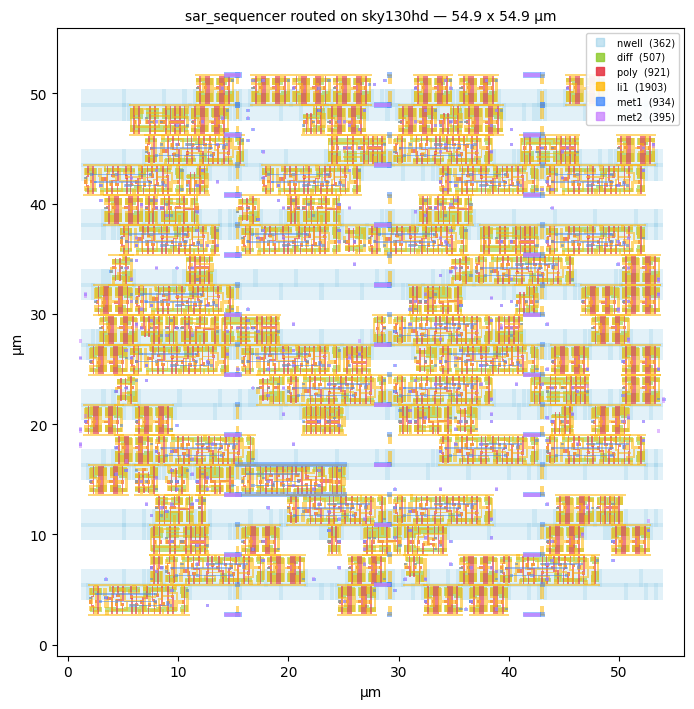

drawn 5,022 of 17,962 polygons (the rest are contacts, vias, wells and text)


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly

LAYERS = [((64,20), "#8ecae6", "nwell", 0.25), ((65,20), "#8ac926", "diff", 0.55),
          ((66,20), "#e63946", "poly",  0.65), ((67,20), "#ffb703", "li1",  0.55),
          ((68,20), "#3a86ff", "met1",  0.50), ((69,20), "#c77dff", "met2", 0.50)]

flat = gdstk.read_gds(GDS_NAME).top_level()[0].copy("f").flatten()
by = {}
for poly in flat.polygons:
    by.setdefault((poly.layer, poly.datatype), []).append(poly.points)

fig, ax = plt.subplots(figsize=(7.2, 7.2))
for key, col, name, a in LAYERS:
    pts = by.get(key, [])
    for q in pts:
        ax.add_patch(MplPoly(q, closed=True, facecolor=col, edgecolor="none", alpha=a))
    ax.plot([], [], "s", color=col, alpha=min(1, a + 0.25), label=f"{name}  ({len(pts)})")

bb = flat.bounding_box()
ax.set_xlim(bb[0][0] - 1, bb[1][0] + 1); ax.set_ylim(bb[0][1] - 1, bb[1][1] + 1)
ax.set_aspect("equal"); ax.set(xlabel="µm", ylabel="µm")
ax.set_title(f"sar_sequencer routed on sky130hd — "
             f"{bb[1][0]-bb[0][0]:.1f} x {bb[1][1]-bb[0][1]:.1f} µm", fontsize=10)
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
plt.tight_layout(); plt.show()
print(f"drawn {sum(len(by.get(k,[])) for k,_,_,_ in LAYERS):,} of {len(flat.polygons):,} polygons "
      f"(the rest are contacts, vias, wells and text)")

In [9]:
# The official sky130 deck. Never raises; reports what it finds.
import os, sys, glob, shutil, subprocess, pathlib, collections
import xml.etree.ElementTree as ET

PDK_HASH = "c6d73a35f524070e85faff4a6a9eef49553ebc2b"   # same pin as the companion notebook
IN_COLAB = "google.colab" in sys.modules

def _sh(cmd, **kw):
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=5400, **kw)
        return r.returncode == 0, (r.stdout or "") + (r.stderr or "")
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"

def drc():
    kl = shutil.which("klayout")
    if kl is None:
        if not IN_COLAB:
            return ("SKIPPED -- klayout binary not found.\n"
                    "  macOS: brew install --cask klayout   Linux: apt-get install klayout")
        print("installing klayout and zstd ...", flush=True)
        _sh("apt-get -qq update && apt-get -qq install -y klayout zstd", shell=True)
        kl = shutil.which("klayout")
        if kl is None:
            return "could not install klayout"

    root = pathlib.Path(os.environ.get("PDK_ROOT", "/content/pdk" if IN_COLAB else "./pdk"))
    deck = glob.glob(str(root / "sky130A/libs.tech/klayout/drc/sky130A_mr.drc"))
    if not deck:
        print("fetching the PDK rule files (~1 min) ...", flush=True)
        root.mkdir(parents=True, exist_ok=True)
        tar = root.parent / "common.tar.zst"
        url = ("https://github.com/chipfoundry/volare/releases/download/"
               f"sky130-{PDK_HASH}/common.tar.zst")
        ok, out = _sh(["curl", "-sL", "--fail", "-o", str(tar), url])
        if not ok or not tar.exists() or tar.stat().st_size == 0:
            return "could not download the PDK:\n" + out[-400:]
        ok, out = _sh(["tar", "--zstd", "-xf", str(tar), "-C", str(root)])
        if not ok:
            ok, out = _sh(f"zstd -d -c {tar} | tar -x -C {root}", shell=True)
        if not ok:
            return "could not unpack the PDK (is zstd installed?):\n" + out[-400:]
        deck = glob.glob(str(root / "sky130A/libs.tech/klayout/drc/sky130A_mr.drc"))
        if not deck:
            return "PDK unpacked but sky130A_mr.drc was not found in it."

    rpt = "drc_sar_sequencer.lyrdb"
    if os.path.exists(rpt):
        os.remove(rpt)
    print(f"running {os.path.basename(deck[0])} on {GDS_NAME} ...", flush=True)
    ok, out = _sh([kl, "-b", "-r", deck[0],
                   "-rd", f"input={GDS_NAME}", "-rd", "top_cell=sar_sequencer",
                   "-rd", f"report={rpt}",
                   "-rd", "feol=true", "-rd", "beol=true", "-rd", "offgrid=true"])
    if not os.path.exists(rpt):
        return "the deck produced no report:\n" + out[-1200:]

    root_el = ET.parse(rpt).getroot()
    n_rules = len(list(root_el.iter("category")))
    cats = collections.Counter(it.findtext("category", "?").strip("\x27")
                               for it in root_el.iter("item"))
    total = sum(cats.values())
    lines = ["", "=" * 56,
             f"OFFICIAL DECK: {total} violations across {n_rules} rule categories",
             "=" * 56]
    for c, n in cats.most_common(40):
        lines.append(f"   {n:>6}  {c}")
    if total == 0:
        lines += ["", "   Clean against the full sky130A deck, feol + beol + offgrid.",
                  f"   {n_rules} categories evaluated -- the deck ran the rules, it did not",
                  "   no-op. The exact count varies a little with the KLayout build."]
    return "\n".join(lines)

print(drc())

installing klayout and zstd ...
fetching the PDK rule files (~1 min) ...
running sky130A_mr.drc on sar_sequencer_sky130hd.gds ...

OFFICIAL DECK: 0 violations across 259 rule categories

   Clean against the full sky130A deck, feol + beol + offgrid.
   259 categories evaluated -- the deck ran the rules, it did not
   no-op. The exact count varies a little with the KLayout build.


---
## 7. Scaling — a 16-channel controller

A single sequencer is 78 cells, which gives a 17.86 µm core. That is too small to implement:
**the power-grid geometry in the flow of Section 8 places its first strap at a 20 µm offset,
which is wider than the whole die**, so placement aborts before it starts. Section 8's finding 4
has the error text and the reason the agents cannot tune around it; the one-line version is that
20 µm does not fit inside 17.86 µm.

The fix is a real structure rather than padding: multi-channel SAR converters are ordinary, and a 16-channel
controller is sixteen of this sequencer sharing one phase clock, reset and start, each keeping its
own comparator input and its own DAC drive.

The risk in writing it is the flattened bus. `d[c*N +: N]` is easy to get wrong in a way that
swaps or aliases channels **while every individual channel still behaves perfectly**. So the
testbench gives every channel a distinct input and checks each one converts its own.

In [10]:
SAR_CONTROLLER_V = r"""
// SPDX-License-Identifier: Apache-2.0
//
// sar_controller -- an NCH-channel SAR controller: NCH independent sequencers
// sharing one phase clock, reset and start.
//
// Why this exists. A single sar_sequencer is 79 Nangate45 cells and gives a
// 17.86 um core, which is below the geometry the OpenLayout flow scripts assume:
// detail_place aborts with PDN-0185 because the hardcoded 20 um power-strap
// offset does not fit inside the die. The benchmark designs that flow targets
// (BlackParrot, Ariane, ethernet) are thousands to hundreds of thousands of
// cells. This wrapper reaches that range with a real structure rather than
// padding: multi-channel SAR converters are ordinary, and every channel here is
// the same sequencer that drives the 8-bit converter in this project.
//
// Sharing, and what is NOT shared. clk, rst_n and start are common, so all
// channels convert in lockstep -- that is the usual arrangement when one timing
// generator serves an array. Each channel keeps its own comparator input and
// its own DAC drive, because those are per-channel analog.
//
// Pin budget. NCH*N DAC lines have to leave the block (they drive NCH physical
// capacitor arrays) so d is flattened and exposed. The conversion results do NOT
// need that bandwidth -- they are read back over a shared bus -- so code is
// multiplexed behind ch_sel. That keeps the port count at 3 + NCH + $clog2(NCH)
// inputs and NCH*N + N + NCH outputs instead of 2*NCH*N.

`default_nettype none

module sar_controller #(
    parameter integer N   = 8,          // bits per channel
    parameter integer NCH = 16          // channels
) (
    input  wire                    clk,
    input  wire                    rst_n,
    input  wire                    start,
    input  wire [NCH-1:0]          cmp,        // one comparator per channel
    input  wire [$clog2(NCH)-1:0]  ch_sel,     // which channel's code to read

    output wire [NCH*N-1:0]        d,          // flattened DAC drive, channel-major
    output wire [N-1:0]            code_bin,   // selected channel, conventional weighting
    output wire [NCH-1:0]          eoc
);

    generate
        if (NCH < 2) begin : g_bad_nch
            illegal_parameter_NCH_must_be_at_least_2 err();
        end
    endgenerate

    wire [N-1:0] code_bin_ch [0:NCH-1];

    genvar c;
    generate
        for (c = 0; c < NCH; c = c + 1) begin : g_ch
            sar_sequencer #(.N(N)) u_seq (
                .clk      (clk),
                .rst_n    (rst_n),
                .start    (start),
                .cmp      (cmp[c]),
                .d        (d[c*N +: N]),
                .phase    (),                  // per-channel observability not brought out
                .code     (),
                .code_bin (code_bin_ch[c]),
                .eoc      (eoc[c])
            );
        end
    endgenerate

    // Read-back mux. Registered would add a cycle to a path that has a whole
    // conversion to settle in; combinational is the honest choice here and the
    // SDC budgets it as an ordinary output.
    assign code_bin = code_bin_ch[ch_sel];

endmodule

`default_nettype wire
"""
TB_CONTROLLER_V = r"""
// SPDX-License-Identifier: Apache-2.0
//
// tb_sar_controller -- checks that each channel converts its OWN input.
// The failure this is built to catch is a flattening slip in d[c*N +: N],
// which swaps or aliases channels while every individual channel still looks
// perfectly well-behaved on its own.

`timescale 1ns/1ps
`default_nettype none

module tb_sar_controller;
    localparam integer N    = 8;
    localparam integer NCH  = 16;
    localparam integer FULL = 1 << N;
    localparam real    VREF = 1.8;
    localparam real    TP   = 100.0;

    reg                    clk = 1'b0, rst_n = 1'b0, start = 1'b0;
    reg  [NCH-1:0]         cmp;
    reg  [3:0]             ch_sel = 4'd0;
    wire [NCH*N-1:0]       d;
    wire [N-1:0]           code_bin;
    wire [NCH-1:0]         eoc;

    real vin [0:NCH-1];
    real vdac[0:NCH-1];
    integer c, k, errs, expect_code, got;
    // SEPARATE loop variables for the combinational block: sharing c/k with the
    // initial block lets the always block clobber the stimulus loop counter
    // mid-iteration, which reads as a channel-16 mismatch on a 16-channel part.
    integer cc, kk;
    real lsb;

    // One ideal DAC + comparator per channel, each fed only by its own slice.
    always @* begin
        for (cc = 0; cc < NCH; cc = cc + 1) begin
            vdac[cc] = 0.0;
            for (kk = 0; kk < N; kk = kk + 1)
                if (d[cc*N + kk]) vdac[cc] = vdac[cc] + VREF / (1 << (kk + 1));
            cmp[cc] = (vin[cc] > vdac[cc]);
        end
    end

    always #(TP/2.0) clk = ~clk;

    sar_controller #(.N(N), .NCH(NCH)) dut (
        .clk(clk), .rst_n(rst_n), .start(start), .cmp(cmp), .ch_sel(ch_sel),
        .d(d), .code_bin(code_bin), .eoc(eoc));

    initial begin
        lsb  = VREF / FULL;
        errs = 0;
        // A DISTINCT level per channel, so an aliased channel cannot pass.
        for (c = 0; c < NCH; c = c + 1) vin[c] = (c*15 + 7) * lsb + lsb/2.0;

        repeat (4) @(posedge clk);
        rst_n = 1'b1;
        repeat (2) @(posedge clk);

        @(negedge clk); start = 1'b1;
        @(posedge eoc[0]); start = 1'b0;
        @(negedge clk);

        for (c = 0; c < NCH; c = c + 1) begin
            ch_sel = c[3:0];
            #1;
            expect_code = c*15 + 7;
            got = code_bin;
            if (got !== expect_code[N-1:0]) begin
                $display("CHANNEL %0d MISMATCH: vin=%0.5f expected %0d got %0d",
                         c, vin[c], expect_code, got);
                errs = errs + 1;
            end
        end

        $display("");
        $display("channels checked : %0d", NCH);
        $display("mismatches       : %0d", errs);
        if (errs != 0) $fatal(1, "FAIL: channel routing is wrong");
        if (eoc !== {NCH{1'b1}}) $fatal(1, "FAIL: not all channels signalled eoc: %b", eoc);
        $display("PASS: every channel converted its own input, all eoc asserted");
        $finish;
    end

    initial begin
        #(TP * 200);
        $fatal(1, "TIMEOUT");
    end
endmodule

`default_nettype wire
"""

(WORK/"sar_controller.v").write_text(SAR_CONTROLLER_V)
(WORK/"tb_sar_controller.v").write_text(TB_CONTROLLER_V)
sh(f"cd {WORK} && iverilog -g2012 -o ctrl.out sar_sequencer.v sar_controller.v tb_sar_controller.v")
print(sh(f"cd {WORK} && ./ctrl.out").replace("$finish", "").strip())

channels checked : 16
mismatches       : 0
PASS: every channel converted its own input, all eoc asserted
tb_sar_controller.v:83:  called at 1516000 (1ps)


Synthesis gives **432 flops, which is exactly 16 × 27** — no channel was optimised away, and the
per-channel structure survived flattening.

| | `sar_controller`, Nangate45 |
|---|---|
| instances | 1374 |
| die | 78.64 × 78.64 µm |
| I/O pins | 175 |
| area | 3342 µm² |

---
## 8. Replicating OpenLayout

**OpenLayout** (Li, Tang, Cheng, Wang, Li, Lan and Cao, ICCAD '26) is a multi-agent physical-design
framework. **Stated plainly, because it should not be left for a reader to work out from the
author list: the last author, Weidong Cao, is my advisor and the paper's corresponding author.**
He suggested this direction and I thank him in the acknowledgements. The five findings below are
criticisms of his group's software, and I would rather you read them knowing that. Each one is
reproducible from the commands given; none depends on taking my word.

The framework: each stage runs a Worker from a proven TCL template, then a **Debugger** that checks the
result against a stage checklist, then an **Optimizer** that reads the attempt history and proposes
parameter changes which run in parallel, best result promoted.

```
floorplan -> macro_place -> detail_place -> cts -> route -> finish
             (candidate      each stage: Worker -> Debugger -> Optimizer
              sampling)
```

It is open-sourced under GPL-3.0 and this notebook is Apache-2.0, so **no substantial portion of
its code is reproduced here** — the clone is kept outside this project and only findings are
reported. One single-line assignment is quoted below, for criticism, because describing it in
prose would make the defect harder to check than it needs to be.

The flow **does** run, and on the controller of Section 7 it produces a clean layout.

**Read the table below as a baseline, not as a result of the agentic system.** It was produced
with `--no-llm`: Worker defaults from the proven TCL templates, with the Debugger and Optimizer
never invoked. It is OpenROAD doing what OpenROAD does. Finding 5 explains why no agent ran, and
the number to compare any future agent result against is this one.

| stage | t | result |
|---|---|---|
| floorplan | 1 s | ok |
| macro_place | — | skipped, `num_macros=0` |
| detail_place | 2 s | WNS +9.83 ns, TNS 0.0 |
| cts | 1 s | WNS +9.65 ns |
| route | 25 s | WNS +9.64 ns, 0 DRC, 23665 µm wirelength |
| finish | 1 s | 166 µW |

*Baseline — Worker defaults, agents not invoked. `goal_met=True` in 33 s.*

A fast, confident number in bold is exactly what the companion notebook trains a reader to
distrust, and this one would deserve it: 33 seconds of templates is not evidence about
multi-agent design-space optimisation. Getting to it surfaced five things.

### 1. Layout snapshots never work as shipped

`openlayout/runner.py` sets, for every OpenROAD subprocess:

```python
env["QT_QPA_PLATFORM"] = "minimal"
```

OpenROAD rejects that value outright — it supports only `offscreen` and `xcb` — and aborts with
`GUI-0077` and signal 6. So `save_image` fails at **every** stage, on **every** machine. The
comment directly above the line reads `# headless image saving`, so the intent was right and the
value is simply wrong: `minimal` is a real Qt platform but carries no rendering backend.

It matters more than a missing picture: those images are what the macro-placement **vision** agents
see. And the failure is silent, because `snapshot()` returns `None` rather than raising. One word,
`minimal` → `offscreen`, and the images render correctly.

### 2. Worker-only mode cannot complete any benchmark design

`--no-llm` on `bp_fe` dies at `detail_place` with `PDN-0233 Failed to generate full power grid` —
which reads like a power-grid configuration fault. It is not. The benchmark's floorplan DEFs
declare macros with **no placement status at all**; placing them *is* the benchmark task. So
candidate sampling returns zero candidates, the flow announces it is "falling back to predefined
floorplan macro positions" that do not exist, and the run fails three stages later without naming
the cause.

### 3. The open release is Nangate45-specific, and `tech.dir` does not change that

`tech.dir` is a config field, which reads as though the PDK is swappable. Beneath it, filenames are
hardcoded (`NangateOpenCellLibrary_typical.lib` in `config.py`, `queries.py` and
`dataflow/rtlmp_backup/netlist.py`) and so are layer names — **46 references across all five stage
scripts**:

| script | refs | controls |
|---|---|---|
| `detail_place.tcl` | 22 | PDN rings, stripes, connects, `set_wire_rc` |
| `floorplan_init.tcl` | 10 | |
| `route.tcl` | 10 | signal/clock routing layer range |
| `cts.tcl` | 2 | |
| `finish.tcl` | 2 | |

Nangate45 has ten metal layers, `metal1..metal10`. sky130 has five, `li1, met1..met5`. There is no
`metal9` to build a power ring on and no `metal8`/`metal9` pair to strap between, so
`add_pdn_ring -layer {metal9 metal10}` and `set sig_max_layer metal9` are not rename-level
changes. **Replicating on sky130 is a port, not a configuration.**

### 4. The flow assumes benchmark-scale designs, and the agents cannot tune around it

The single sequencer gives a 17.86 µm core. `detail_place` aborts:

```
[ERROR PDN-0185] Insufficient width (17.86 um) to add straps on layer metal8
in grid "core_grid" with total strap width 3.9 um and offset 20.0 um.
```

The strap offset alone exceeds the die. The Optimizer's parameter space for that stage is
`place_density, halo_um, pdn_pitch (40..80), routability_driven, timing_driven, run_resizer` — the
**offset is not in it**, and no pitch in range fits a 17.86 µm die. The agent loop cannot recover
from a geometric failure by tuning parameters.

This is why Section 7 exists: the 16-channel controller is what puts the design back inside the
size range the flow's geometry assumes.

### 5. A baseline that already meets the goal leaves the agents nothing to do

On the 16-channel controller the Worker's *default* parameters meet the goal on the first attempt:
+9.64 ns of slack, zero DRC. The Debugger therefore reports the stage clean and the Optimizer is
never invoked. Enabling the agents against this configuration would cost almost nothing and
demonstrate almost nothing.

That is a property of the experiment, not of the framework — and it is the same mistake as
measuring ENOB on a near-DC ramp. **A design-space optimiser can only be observed where the design
space contains a problem.** To see the loop work, the goal has to bite: tighten the clock until
setup fails, or set an area or power limit below the baseline, then ask whether the agents recover
it. The table above is the baseline any agent result has to be compared against, which is why it
was worth establishing first.

---
## 9. What transfers

- **Two independent statements of the same design are a cheap review.** The netlist and the RTL
  disagreed twice. Neither disagreement was a logic error and neither was found by simulation.
- **A passing testbench is evidence about the model.** Section 3 shows a real defect that the
  testbench cannot detect at any coverage, because the defect lives in the interface between the
  digital block and the analog it drives.
- **Half-cycle paths that close through analog need an explicit budget, and the budget is an
  assumption until it is measured.** Saying so in the constraint file costs one comment.
- **Name the failing thing, not the stage that noticed.** Three of the five OpenLayout findings
  presented as errors several stages downstream of their cause.
- **Establish the baseline before turning on the optimiser.** Otherwise there is nothing to compare
  against, and an optimiser with nothing to fix looks identical to one that works.

---
## 10. Reproducing this

The simulations above run from a single upload: the RTL and testbenches are embedded as strings,
written to disk, and compiled by Icarus Verilog installed in Section 1.

The physical-implementation numbers are records. `sar_sequencer` on sky130hd reproduces with
OpenROAD via the command in Section 6; the OpenLayout results reproduce against the upstream
repository at `github.com/fenggev56/OpenLayout` with the one-word patch of finding 1 applied.

Licensed Apache 2.0. OpenLayout is GPL-3.0 and none of its code appears here.

In [11]:
# Runtime, measured rather than asserted.
import time, sys
_t0 = globals().get("T_START")
if _t0:
    print(f"notebook elapsed, first cell to here: {(time.time()-_t0)/60:.2f} min"
          f"  ({'Colab' if 'google.colab' in sys.modules else 'local'})")

notebook elapsed, first cell to here: 0.90 min  (Colab)
